# &laquo;Машинное обучение&raquo;, AI Masters

### Домашняя работа №7. Бинарное дерево решений, случайный лес.

### Задача 1 (2 балла)

1. закончить реализацию `ClassificationDecisionTree` в decision_tree
    1. реализовать feature_importance_ (для этого метода теста нет, подойдет реализацию любого варианта, базовый способ - рекурсивно суммировать по всем `self.feature_id` `self.q_value_max` и вывести суммы. 
    2. проверить корректность predict 
2. реализовать `BaseSampler`, `ObjectSampler` и `FeatureSampler`. `BaseSampler` - базовый класс, у которого должен быть реализован метода `sample_indices` - вернуть индексы сэмплов. `ObjectSampler` сэплирует объекты, `FeatureSampler` - признаки.
3. реализовать `RandomForestClassifier` в random_forest (predict/predict_proba).

Обратите внимение, что в random_forest в качестве `base_estimator` предполагается использовать `DecisionTreeClassifier` из sklearn, использовать вашу реализацию решающего дерева необязательно. <br> Пример запуска тестов 
- `python -m unittest discover sem_dt_rf/decision_tree/tests`
- `python -m unittest discover sem_dt_rf/random_forest/tests` 

Или через `pytest`
- `python -m pytest sem_dt_rf/decision_tree/tests/test_criterio.py`

**Запустите проверку прямо из этого .ipynb**

### Задача 2 (1 балл)

Для регрессионного дерева необходимо использовать такой критерий:

$$H(R) = \min_c \frac{1}{|R|} \sum_{(x_i, y_i) \in R} (y_i - c)^2$$

Докажите, что минимум $H(R)$ достигается при следующем $c$:

$$ c = \frac{1}{|R|} \sum_{(x_j, y_j) \in R} y_j$$

Решается задача минимизации квадратичной функции одной переменной. Решение очевидно находится как точка минимума параболы $-\frac{b}{2a}$ 

### Задача 3 (3 балла)

Реализуйте `class RegressionDecisionTree(DecisionTree)` -- регрессионное дерево.

* В качестве критерия необходимо использовать критерий, определённый в пункте 2 (для этого в коде есть заглушка `MSECriterion`).
* В качестве `predict` необходимо использовать среднее значение ответов по всем объектам в листе. В коде нет готовой заглушки, реализуйте по аналогии с `class ClassificationDecisionTree(DecisionTree):`.

Сгенерируйте однопризнаковую выборку для тестирования дерева и покажите работу дерева на этой выборке (пример см. ниже, можно использовать свою версию). Отобразите на одном графике `predict` алгоритма и значение признака. Что меняется при изменении параметра глубины? Сделайте выводы.

In [65]:
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [66]:
# generate example
x_shape = 300
x = np.arange(x_shape) / 100
y = x**3 * np.sin(x**3) + np.random.random(x_shape)

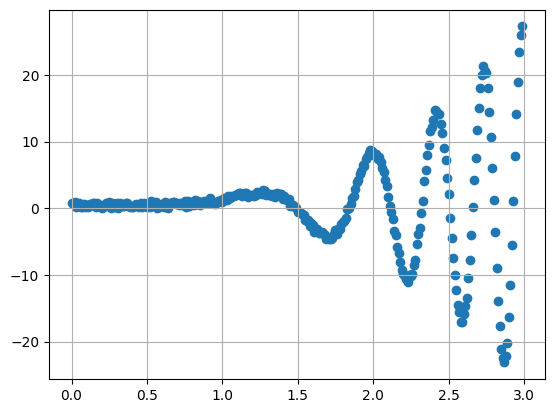

In [67]:
plt.scatter(x, y)
plt.grid()
plt.show()

### Задача 4 (4 балла)

Протестируйте различные реализации **случайного леса** на `fetch_covtype` датасете (можно загрузить с помощью `sklearn.datasets.fetch_covtype`). Возможно, поможет ноутбук с семинара `ensembles_seminar.ipynb`.

Для честного сравнения старайтесь использовать похожий набор гиперпараметров.

Сравните следующие модели:
- ваша реализация (`import RandomForestClassifier as MyRandomForestClassifier` ниже)
- Scikit-learn [`RandomForestClassifier`](https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html)
- XGBoost [`XGBRFClassifier`](https://xgboost.readthedocs.io/en/stable/tutorials/rf.html)
- LightGBM [`LGBMClassifier`](https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMModel.html) см. параметр `boosting_type`

Что нужно сделать: 
- Разбейте данные на train и test. 
- Оцените качество алгоритмов по метрике [`balanced_accuracy_score`](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html)
- Оцените время работы `train` и `predict`
- Найдите, в каких из модулей (помимо вашего) реализовано вычисление важностей признаков. Сравните выдаваемые importances в моделях с такой функцией
- Сделайте выводы

In [68]:
# import sys
# sys.path.extend(['/Users/alkrasnov/Documents/AM_ML_2_25']) # change your path

In [69]:
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier as MyRandomForestClassifier

In [76]:
from sklearn.datasets import fetch_covtype
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import xgboost as xgb
from sem_dt_rf.random_forest.random_forest import RandomForestClassifier as MyRandomForestClassifier

In [71]:
cov_type = fetch_covtype()

In [72]:
cov_type.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [73]:
x_train, x_test, y_train, y_test = train_test_split(cov_type['data'], cov_type['target'] - 1)

In [ ]:
import time

models = [
    ('my', MyRandomForestClassifier())
    ('sklearn', RandomForestClassifier(n_jobs=-1, class_weight='balanced')), 
    # ('LightGBM', lgb.LGBMClassifier(boosting_type="rf", n_jobs=-1, class_weight='balanced')),
    ('XGBoost', xgb.XGBRFClassifier(n_jobs=-1))
    ]

train_times = []
predict_times = []
scores = []
importances = []

for name, model in models:
    print(f"Fitting {name} model")
    
    start = time.time()
    model.fit(x_train, y_train)
    train_times.append(time.time() - start)
    
    start = time.time()
    y_pred = model.predict(x_test)
    predict_times.append(time.time() - start)
        
    importances.append(model.feature_importances_)
        
    scores.append(balanced_accuracy_score(y_true=y_test, y_pred=y_pred))

Fitting sklearn model
Fitting LightGBM model


[LightGBM] [Fatal] Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /__w/1/s/lightgbm-python/src/boosting/rf.hpp, line 36 .



LightGBMError: Check failed: (config->bagging_freq > 0 && config->bagging_fraction < 1.0f && config->bagging_fraction > 0.0f) || (config->feature_fraction < 1.0f && config->feature_fraction > 0.0f) at /__w/1/s/lightgbm-python/src/boosting/rf.hpp, line 36 .


In [ ]:
import pandas as pd

results = pd.DataFrame({'model': [name for name, _ in models], 'train_time': train_times, 'predict_time': predict_times, 'score': scores})

In [ ]:
results

,model,train_time,predict_time,score
0,sklearn,10.061580,0.569709,0.903197
1,XGBoost,5.688319,0.186696,0.582491


In [ ]:
def logp(x):
    return np.where(x > 1e-4, np.log(x), 0)

def divp(x, y):
    return np.where(y > 1e-4, x / y, 0)

def kl_divergence(p, q):
    return np.sum(p * logp(divp(p, q)))

def kl_distance(p, q):
    return kl_divergence(p, q) + kl_divergence(q, p)

In [ ]:
from itertools import product

distances = np.zeros((len(models), len(models)))

for i, j in product(range(len(models)), repeat=2):
    distances[i, j] = kl_distance(importances[i], importances[j])

/tmp/ipykernel_33662/1716440444.py:2: RuntimeWarning: divide by zero encountered in log
  return np.where(x > 1e-4, np.log(x), 0)
/tmp/ipykernel_33662/1716440444.py:5: RuntimeWarning: divide by zero encountered in divide
  return np.where(y > 1e-4, x / y, 0)
/tmp/ipykernel_33662/1716440444.py:5: RuntimeWarning: invalid value encountered in divide
  return np.where(y > 1e-4, x / y, 0)


In [ ]:
distances

array([[0.        , 2.35798051],
       [2.35798051, 0.        ]])